# 1. Data Audit, Cleaning and Preprocessing

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load and read dataset
df = pd.read_csv("Regulatory Affairs of Road Accident Data 2020 India.csv")

In [3]:
df.head()

,Million Plus Cities,Cause category,Cause Subcategory,Outcome of Incident,Count
0,Agra,Traffic Control,Flashing Signal/Blinker,Greviously Injured,0.0
1,Agra,Traffic Control,Flashing Signal/Blinker,Minor Injury,0.0
2,Agra,Traffic Control,Flashing Signal/Blinker,Persons Killed,0.0
3,Agra,Traffic Control,Flashing Signal/Blinker,Total Injured,0.0
4,Agra,Traffic Control,Flashing Signal/Blinker,Total number of Accidents,0.0


In [4]:
df.shape

(9550, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9550 entries, 0 to 9549
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Million Plus Cities  9550 non-null   object 
 1   Cause category       9550 non-null   object 
 2   Cause Subcategory    9550 non-null   object 
 3   Outcome of Incident  9550 non-null   object 
 4   Count                9547 non-null   float64
dtypes: float64(1), object(4)
memory usage: 373.2+ KB


In [6]:
df.describe()

,Count
count,9547.000000
mean,103.627632
std,275.189303
min,0.000000
25%,0.000000
50%,12.000000
75%,70.500000
max,3148.000000


In [7]:
# Checking for duplicates
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows : {duplicates}')

Number of duplicate rows : 0


In [8]:
# checking for missing values
df.isnull().sum()

Million Plus Cities    0
Cause category         0
Cause Subcategory      0
Outcome of Incident    0
Count                  3
dtype: int64

In [9]:
# Show all rows where at least one column is null
print(df[df.isnull().any(axis = 1)])

     Million Plus Cities            Cause category Cause Subcategory  \
7056             Gwalior  Impacting Vehicle/Object         Other Non   
7057             Gwalior  Impacting Vehicle/Object         Other Non   
7058             Gwalior  Impacting Vehicle/Object         Other Non   

     Outcome of Incident  Count  
7056  Greviously Injured    NaN  
7057      Persons Killed    NaN  
7058        Minor Injury    NaN  


In [10]:
# Filter only Gwalior rows
gwalior_data = df[df['Million Plus Cities'] == 'Gwalior']

gwalior_mean = gwalior_data['Count'].mean()
gwalior_median = gwalior_data['Count'].median()
gwalior_mode = gwalior_data['Count'].mode()[0]  

print("Gwalior Mean:", gwalior_mean)
print("Gwalior Median:", gwalior_median)
print("Gwalior Mode:", gwalior_mode)

Gwalior Mean: 145.26063829787233
Gwalior Median: 21.5
Gwalior Mode: 0.0


- The Count values for Gwalior are highly skewed. The mean (145.26) is much higher than the median (21.5) because of a few extreme accident counts, which would lead to overestimation if used for imputation.
- Since only 3 rows out of 9550 have missing values in the Count column, imputing them with 0 (mode) would not significantly affect the overall analysis. However, from a better practice perspective and to avoid underestimation and maintain consistency with the city’s accident distribution, the median was preferred as the imputation value.

In [11]:
# Imputing the null values with the median 
df.loc[(df['Million Plus Cities'] == 'Gwalior') & (df['Count'].isnull()), 'Count'] = gwalior_median

In [12]:
df.isnull().sum()

Million Plus Cities    0
Cause category         0
Cause Subcategory      0
Outcome of Incident    0
Count                  0
dtype: int64

In [13]:
df['Count'] = df['Count'].astype(int)
print(df['Count'].dtype)

int64


In [14]:
# Total number of unique values in each of the columns
df.nunique()

Million Plus Cities     50
Cause category           6
Cause Subcategory       35
Outcome of Incident      5
Count                  797
dtype: int64

# 3. Exploratory Data Analysis (EDA)

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

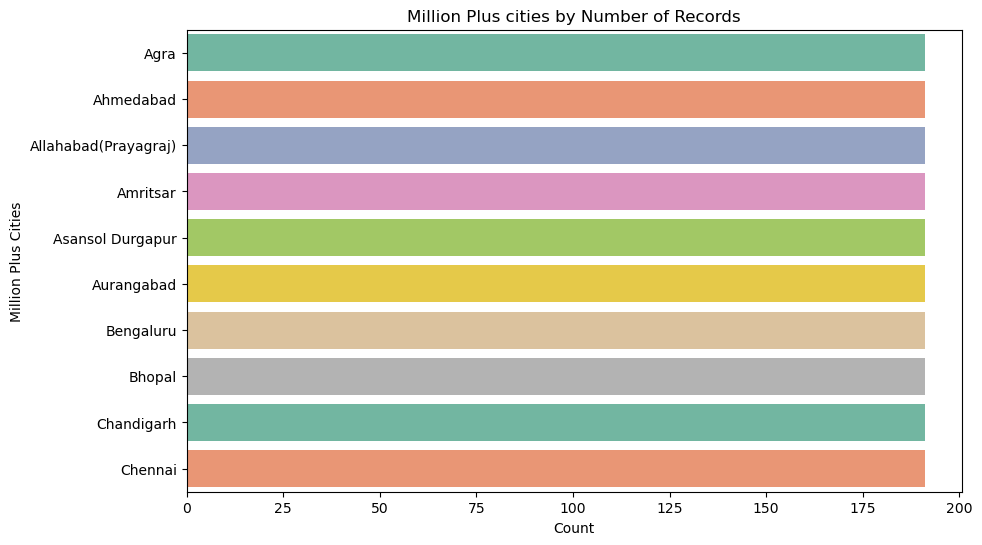

In [16]:
# Distribution of accidents by city
plt.figure(figsize = (10,6))
sns.countplot(data = df, y = 'Million Plus Cities', order = df['Million Plus Cities'].value_counts().head(10).index, palette = 'Set2')
plt.title('Million Plus cities by Number of Records')
plt.xlabel('Count')
plt.ylabel('Million Plus Cities')
plt.show()

- The Million Plus Cities column has 50 unique cities, and each city appears 191 times in the dataset. This shows that the dataset is uniformly distributed across cities.
- It means the data is not biased toward one city having more records than another. Instead, the variation in accidents will come from the values in the Count column, not from the number of rows per city.

In [17]:
df['Million Plus Cities'].value_counts()

Million Plus Cities
Agra                    191
Ahmedabad               191
Allahabad(Prayagraj)    191
Amritsar                191
Asansol Durgapur        191
Aurangabad              191
Bengaluru               191
Bhopal                  191
Chandigarh              191
Chennai                 191
Coimbatore              191
Delhi                   191
Dhanbad                 191
Faridabad               191
Ghaziabad               191
Gwalior                 191
Hyderabad               191
Indore                  191
Jabalpur                191
Jaipur                  191
Jamshedpur              191
Jodhpur                 191
Kannur                  191
Kanpur                  191
Khozikode               191
Kochi                   191
Kolkata                 191
Kollam                  191
Kota                    191
Lucknow                 191
Ludhiana                191
Madurai                 191
Mallapuram              191
Meerut                  191
Mumbai                  191


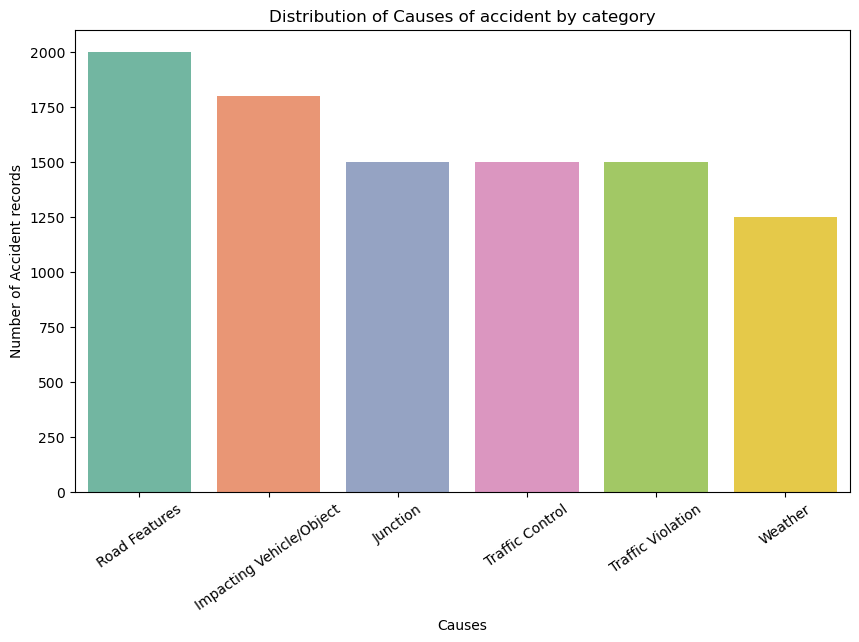

In [18]:
# Distribution of accidents by cause category
plt.figure(figsize = (10, 6))
sns.countplot(data = df, x = 'Cause category', order = df['Cause category'].value_counts().index, palette = 'Set2')
plt.title('Distribution of Causes of accident by category')
plt.xlabel('Causes')
plt.ylabel('Number of Accident records')
plt.xticks(rotation = 35)
plt.show()

- Most accident records are related to road features, while weather-related accidents are the least reported.

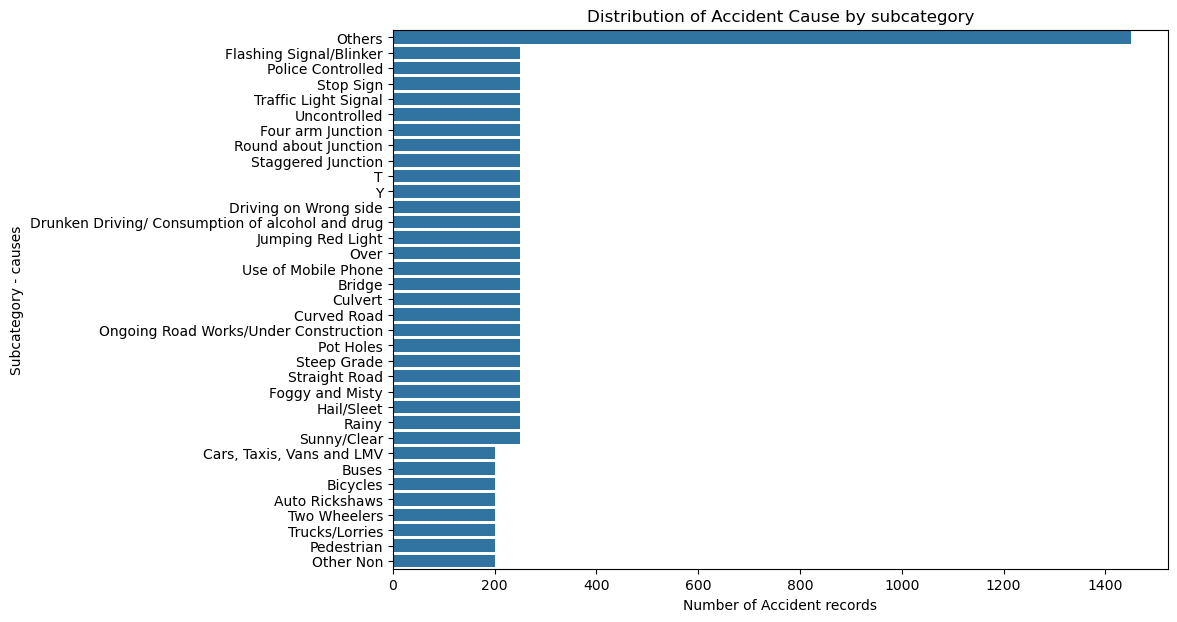

In [19]:
# Distribution of Accidents by cause subcategory
plt.figure(figsize = (10, 7))
sns.countplot(data = df, y = 'Cause Subcategory', order = df['Cause Subcategory'].value_counts().index)
plt.title('Distribution of Accident Cause by subcategory')
plt.xlabel('Number of Accident records')
plt.ylabel('Subcategory - causes')
plt.show()

- Most incidents fall under ‘Others’, while specific causes and vehicle types show relatively uniform counts, indicating diverse but evenly distributed factors.

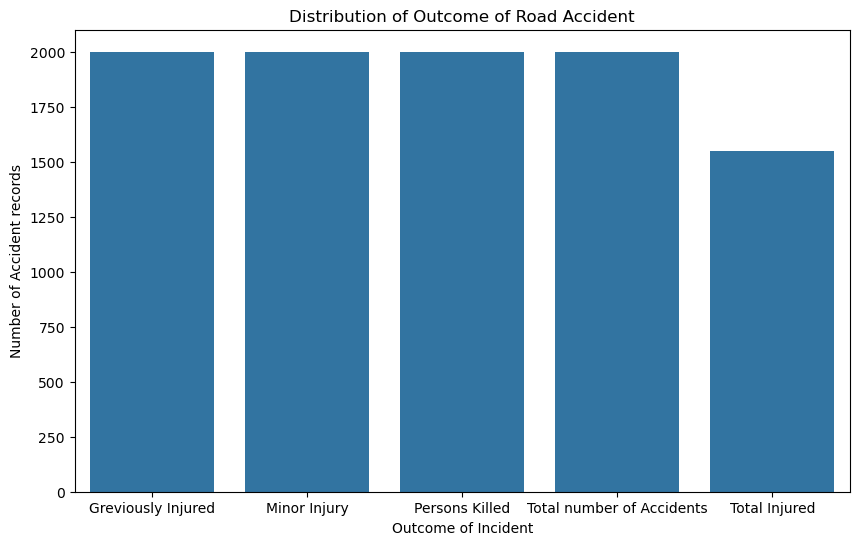

In [20]:
# Distribution of outcome of Incidents
plt.figure(figsize =(10,6))
sns.countplot(data = df, x = 'Outcome of Incident', order = df['Outcome of Incident'].value_counts().index)
plt.title("Distribution of Outcome of Road Accident")
plt.xlabel('Outcome of Incident')
plt.ylabel('Number of Accident records')
plt.show()

- The Outcome of Incident distribution shows that categories like Grievously Injured, Minor Injury, Persons Killed, and Total number of Accidents are equally represented (2000 records each), while Total Injured has fewer records (1550).

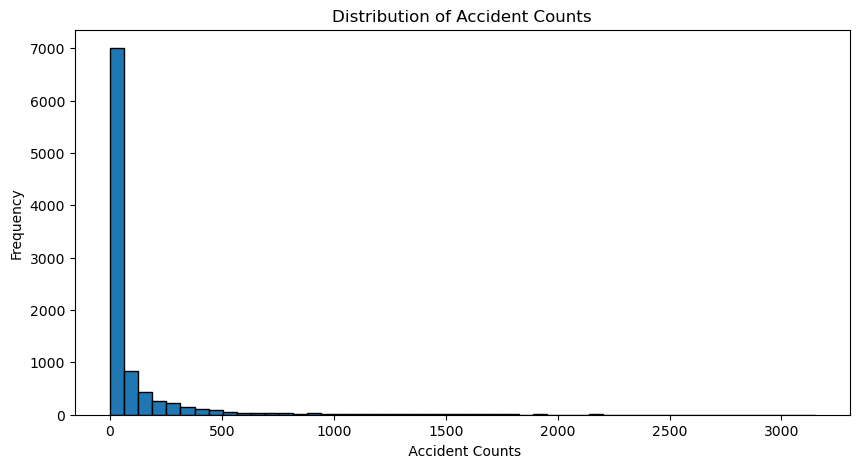

In [21]:
plt.figure(figsize = (10,5))
plt.hist(df['Count'], bins = 50, edgecolor = 'black')
plt.title("Distribution of Accident Counts")
plt.xlabel(" Accident Counts")
plt.ylabel("Frequency")
plt.show()

- The histogram of the Count column shows a highly right-skewed distribution. Most accident records have very low counts (0–100), while very high accident counts are rare but present, creating a long tail up to ~3000.
- This indicates the presence of outliers and suggests that the majority of accidents are small in number, but a few extreme cases contribute disproportionately high counts.

# Bivariate Analysis

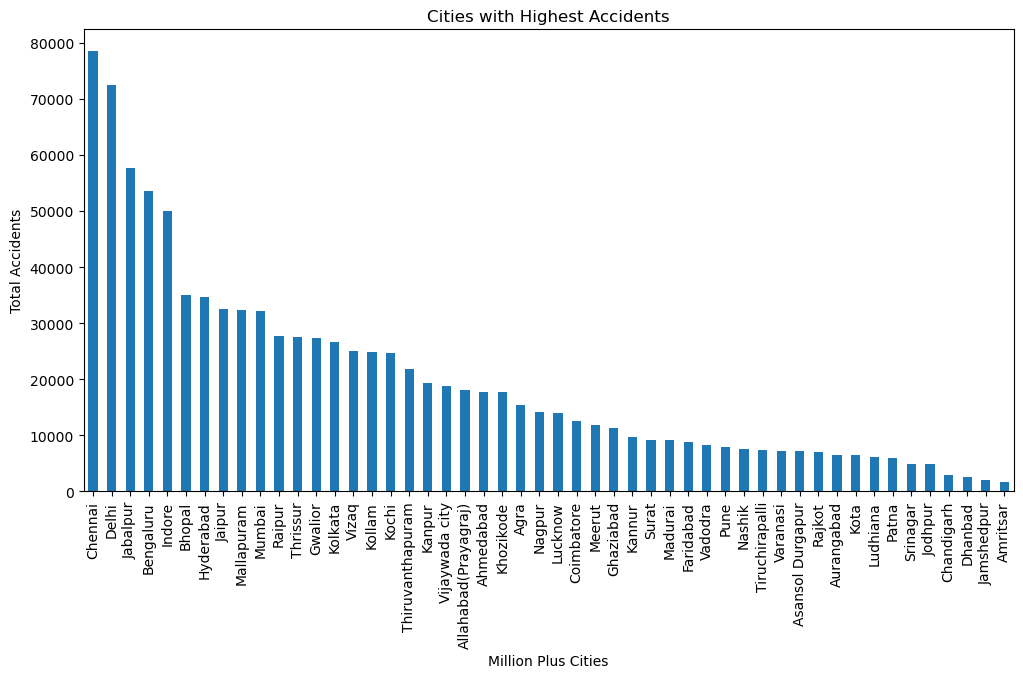

In [22]:
city_accidents = df.groupby('Million Plus Cities')['Count'].sum().sort_values(ascending = False)

plt.figure(figsize = (12,6))
city_accidents.plot(kind = 'bar')
plt.title("Cities with Highest Accidents")
plt.ylabel("Total Accidents")
plt.show()


- Chennai and Delhi are the leading states with the largest accident volumes; there’s a sharp drop after these two

In [23]:
df.groupby(['Cause category', 'Outcome of Incident'])['Count'].sum()

Cause category            Outcome of Incident      
Impacting Vehicle/Object  Greviously Injured           20553
                          Minor Injury                 30004
                          Persons Killed               13563
                          Total number of Accidents    58736
Junction                  Greviously Injured           20532
                          Minor Injury                 29983
                          Persons Killed               13542
                          Total Injured                50515
                          Total number of Accidents    58736
Road Features             Greviously Injured           20532
                          Minor Injury                 29983
                          Persons Killed               13540
                          Total Injured                50515
                          Total number of Accidents    58736
Traffic Control           Greviously Injured           20532
                          Minor I

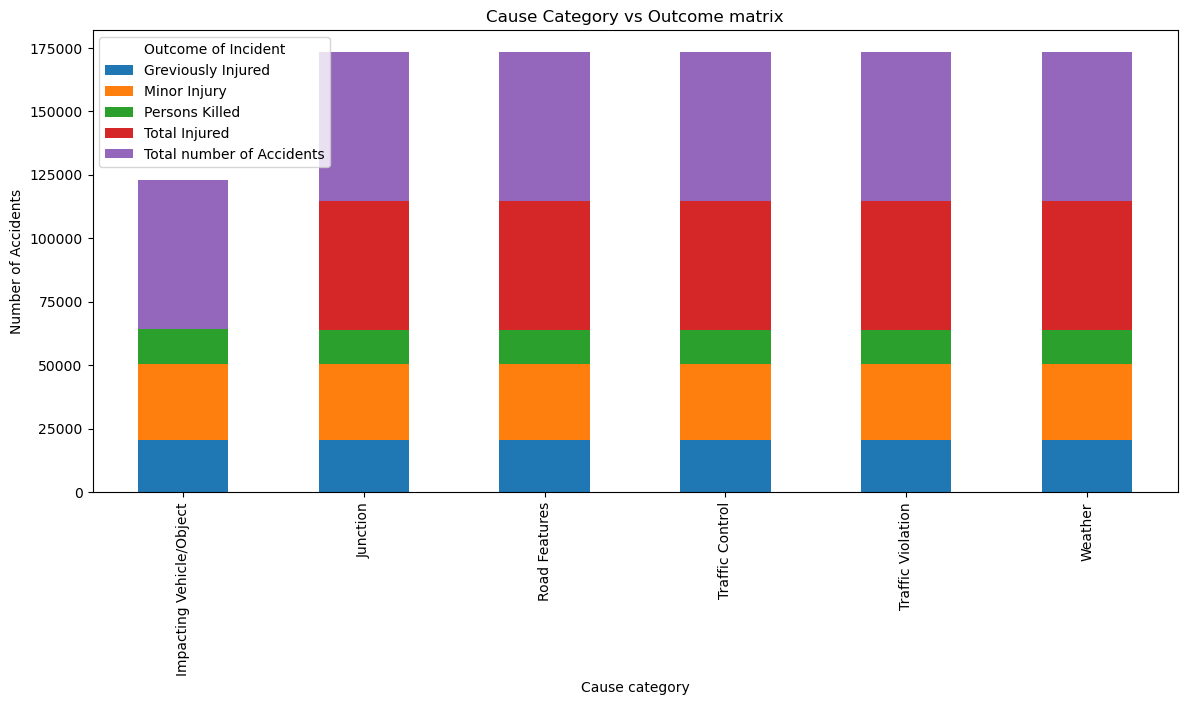

In [25]:
cause_outcomes = df.groupby(['Cause category', 'Outcome of Incident'])['Count'].sum().unstack()

cause_outcomes.plot(kind = 'bar', stacked = True, figsize = (14,6))
plt.title("Cause Category vs Outcome matrix")
plt.ylabel("Number of Accidents")
plt.show()


- Injury cases (minor and grievous) dominate across all causes.
- Fatalities (persons killed) form a small portion compared to injuries.
- Accident outcome pattern is consistent across all cause types.

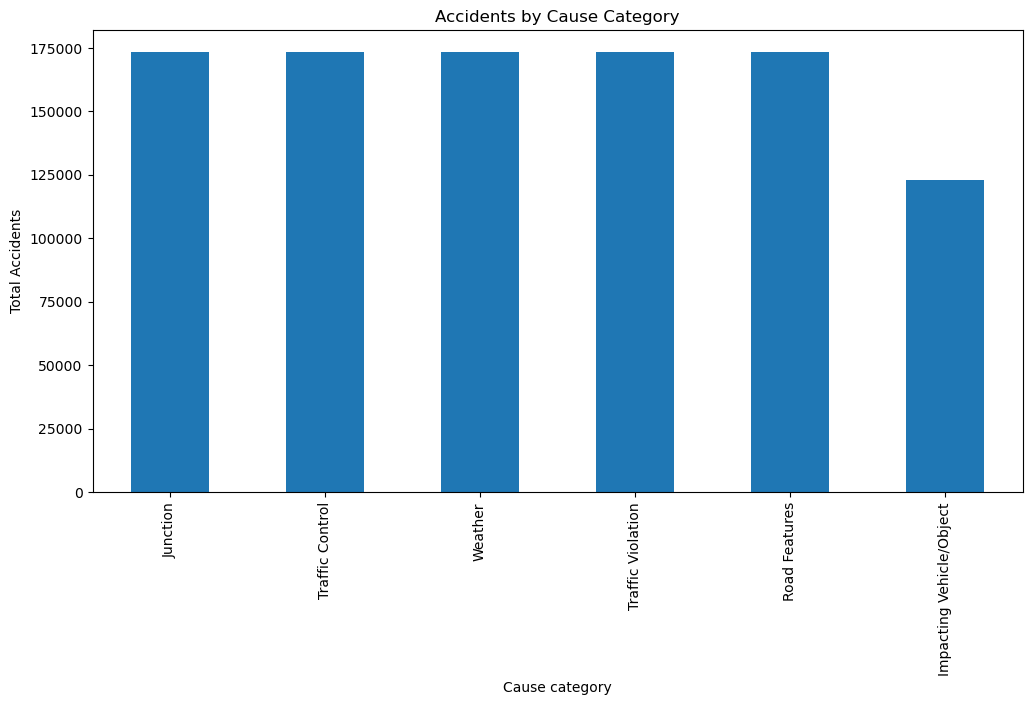

In [26]:
cause_accidents = df.groupby('Cause category')['Count'].sum().sort_values(ascending = False)

plt.figure(figsize = (12,6))
cause_accidents.plot(kind = 'bar')
plt.title("Accidents by Cause Category")
plt.ylabel("Total Accidents")
plt.show()


- All categories except Impacting Vehicle/Object show very similar accident counts, roughly around 175,000 accidents each.
- The Impacting Vehicle/Object category has a significantly lower count, around 125,000 accidents, indicating it contributes less to the total accidents compared to other causes.

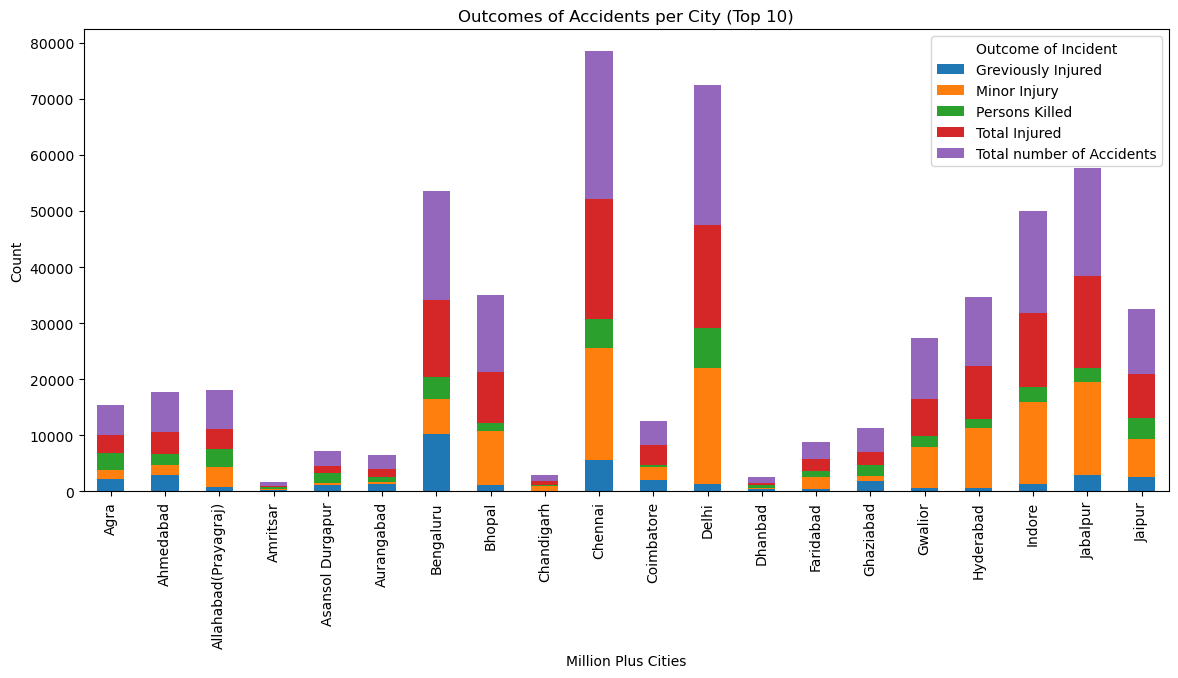

In [27]:
city_outcomes = df.groupby(['Million Plus Cities', 'Outcome of Incident'])['Count'].sum().unstack()

city_outcomes.head(20).plot(kind='bar', stacked=True, figsize=(14,6))
plt.title("Outcomes of Accidents per City (Top 10)")
plt.ylabel("Count")
plt.show()


- Injuries far exceed fatalities in every city; minor injuries > grievous injuries consistently.
- Cities with more accidents also show more total injured.

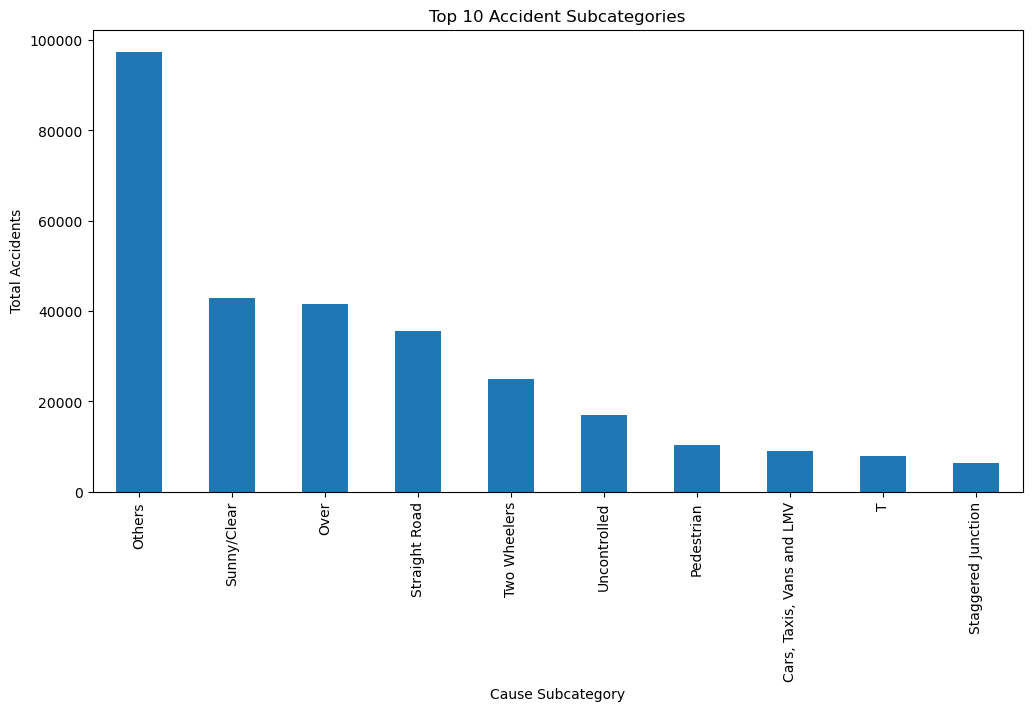

In [28]:
subcat_accidents = df[df['Outcome of Incident'] == 'Total number of Accidents']
subcat_accidents = subcat_accidents.groupby('Cause Subcategory')['Count'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
subcat_accidents.plot(kind='bar')
plt.title("Top 10 Accident Subcategories")
plt.ylabel("Total Accidents")
plt.show()


- 'Others' is the single largest subcategory by a wide margin - indicates unclear labeling; actionability would improve if this bucket is broken down

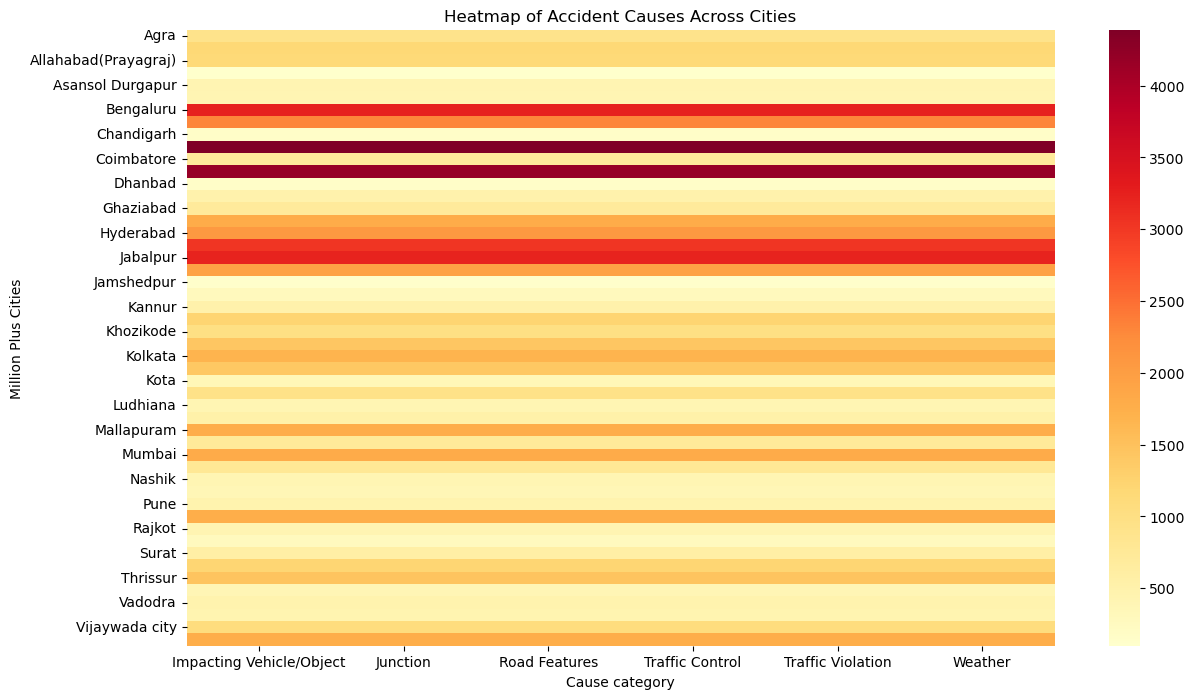

In [29]:
pivot = df[df['Outcome of Incident'] == 'Total number of Accidents']
pivot = pivot.pivot_table(values='Count', index='Million Plus Cities', columns='Cause category', aggfunc='sum', fill_value=0)

plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Heatmap of Accident Causes Across Cities")
plt.show()


- Impacting Vehicle/Object dominates across almost every city; it’s the leading cause everywhere.
- Traffic Violations are the next broad contributor; Weather and Traffic Control consistently contribute the least.